In [1]:
from sklearn.metrics import auc, roc_auc_score, precision_recall_curve, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import pandas as pd 
import numpy as np 
import seaborn 

In [24]:
df = pd.read_csv('tmp.csv')
X = df.drop(['click'], axis=1) 
y = df[['click']].to_numpy().astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.1, shuffle=True)


from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
numCols, catCols = ['a', 'b', 'c'], ['d']
prep = ColumnTransformer([
    ('num', StandardScaler(), numCols),
    ('cat', OneHotEncoder(), catCols),
])
X_train = prep.fit_transform(X_train)
X_test = prep.transform(X_test)


device = 'cpu'

class MLP(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super(MLP, self).__init__()
        self.input = kwargs['input']
        self.output = kwargs['output']
        self.hidden = kwargs['hidden']
        self.dropout = kwargs['dropout']
        self.layers = nn.Sequential(*[
            nn.Linear(self.input, self.hidden),
            nn.BatchNorm1d(self.hidden),
            nn.ReLU(),
            nn.Dropout(p=self.dropout),
            nn.Linear(self.hidden, self.hidden),
            nn.BatchNorm1d(self.hidden),
            nn.ReLU(),
            nn.Dropout(p=self.dropout),
            nn.Linear(self.hidden, self.output),
            nn.Sigmoid(),
        ])
        
    def forward(self, x):
        return self.layers(x)

def eval_package(y, y_pred, y_prob):
    ret = dict()
    ret['prec'] = precision_score(y, y_pred)
    ret['rec'] = recall_score(y, y_pred)
    ret['roc_auc'] = roc_auc_score(y, y_prob)
    recall, precision, _ = precision_recall_curve(y, y_prob)
    ret['pr_auc'] = auc(precision, recall)
    return ret
    
def pred(model, x, threshold = 0.5):
    model.eval()
    with torch.no_grad():
        y_prob = model(x)
        y_pred = (y_prob > threshold)
    return y_pred, y_prob

def eval(model, x, y, criterion):
    y_pred, y_prob = pred(model, x)
    ret = dict()
    ret['loss'] = criterion(y_prob, y).item()
    ret.update(eval_package(y.numpy(), y_pred.numpy(), y_prob.numpy()))
    return ret

def train_epoch(model, x, y, optimizer, criterion, batch_size=128):
    loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=True)
    model.train()
    train_loss = 0.0
    for i, (x, y) in enumerate(loader):
        optimizer.zero_grad()
        y_prob = model(x)
        loss = criterion(y_prob, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f'train: loss {train_loss / len(loader)}')
    return model

def run(model, x, y, x_eval, y_eval, optimizer, criterion, epochs=3, batch_size=128):
    for epoch in range(epochs):
        model = train_epoch(model, x, y, optimizer, criterion, batch_size)
        print(f'eval: {eval(model, x, y, criterion)}')
        print(f'eval: {eval(model, x_eval, y_eval, criterion)}')
    return model

model = MLP(**{'input':X_train.shape[-1], 'output':y_train.shape[-1], 'hidden': 128, 'dropout': 0.2})

y_train_tensor = torch.as_tensor(y_train, dtype=torch.float32)
pos_weight = (y_train_tensor == 0.).sum() * 2 / (y_train_tensor == 0.).sum()
print(pos_weight)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.as_tensor(pos_weight, dtype=torch.float32))
optimizer = optim.Adam(model.parameters(), lr = 0.001)
run(
    model, 
    torch.as_tensor(X_train, dtype=torch.float32), torch.as_tensor(y_train, dtype=torch.float32), torch.as_tensor(X_test, dtype=torch.float32), torch.as_tensor(y_test, dtype=torch.float32),
    optimizer,
    criterion,
    epochs=3,
    batch_size=128,
)

tensor(2.)
train: loss 0.7330111308361996
eval: {'loss': 0.7092362642288208, 'prec': 0.968213058419244, 'rec': 0.5684741488020176, 'roc_auc': 0.9964845651030173, 'pr_auc': 0.9353554508293641}
eval: {'loss': 0.7096414566040039, 'prec': 0.9642857142857143, 'rec': 0.5510204081632653, 'roc_auc': 0.9964158624359183, 'pr_auc': 0.9340022283995288}
train: loss 0.709397507069463
eval: {'loss': 0.701208233833313, 'prec': 0.934421768707483, 'rec': 0.866078184110971, 'roc_auc': 0.9986812018423247, 'pr_auc': 0.9735663486246384}
eval: {'loss': 0.701098620891571, 'prec': 0.9451371571072319, 'rec': 0.8594104308390023, 'roc_auc': 0.9985894975209458, 'pr_auc': 0.9731588283939495}
train: loss 0.7062145501205866
eval: {'loss': 0.7003049254417419, 'prec': 0.9499231950844854, 'rec': 0.7798234552332913, 'roc_auc': 0.9982194729834797, 'pr_auc': 0.9647442973673437}
eval: {'loss': 0.7006632089614868, 'prec': 0.9445983379501385, 'rec': 0.7732426303854876, 'roc_auc': 0.9981423402432773, 'pr_auc': 0.96163872259739

MLP(
  (layers): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

In [25]:
from sklearn.isotonic import IsotonicRegression

def calibration(model, x, y):
    y_pred, y_prob = pred(model, x)
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(y_prob.numpy().squeeze(), y.numpy().squeeze())
    return calibrator

def calibrated_pred(model, x, calibrator, threshold=0.5):
    y_pred, y_prob = pred(model, x)
    calibrated_prob = calibrator.transform(y_prob.numpy())
    return (calibrated_prob > 0.5), calibrated_prob

calibrator = calibration(model, torch.as_tensor(X_train, dtype=torch.float32), torch.as_tensor(y_train, dtype=torch.float32))
y_pred, y_prob = pred(model, torch.as_tensor(X_test, dtype=torch.float32))
y_pred, y_prob = y_pred.numpy().astype(np.float32), y_prob.numpy().astype(np.float32)
y_calibrated_pred, y_calibrated_prob = calibrated_pred(model, torch.as_tensor(X_test, dtype=torch.float32), calibrator)

print(eval_package(y_test, y_calibrated_pred, y_calibrated_prob))
print(eval_package(y_test, y_pred, y_prob))


{'prec': 0.8974358974358975, 'rec': 0.873015873015873, 'roc_auc': 0.9981534895228796, 'pr_auc': 0.9617087128008028}
{'prec': 0.9445983379501385, 'rec': 0.7732426303854876, 'roc_auc': 0.9981423402432773, 'pr_auc': 0.9616387225973966}


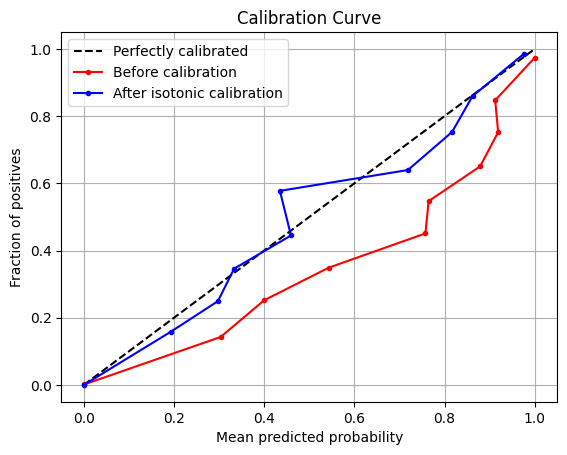

In [26]:

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Plot
plt.figure()
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(*calibration_curve(y_test, y_prob, n_bins=10), 'r.-', label='Before calibration')
plt.plot(*calibration_curve(y_test, y_calibrated_prob, n_bins=10), 'b.-', label='After isotonic calibration')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

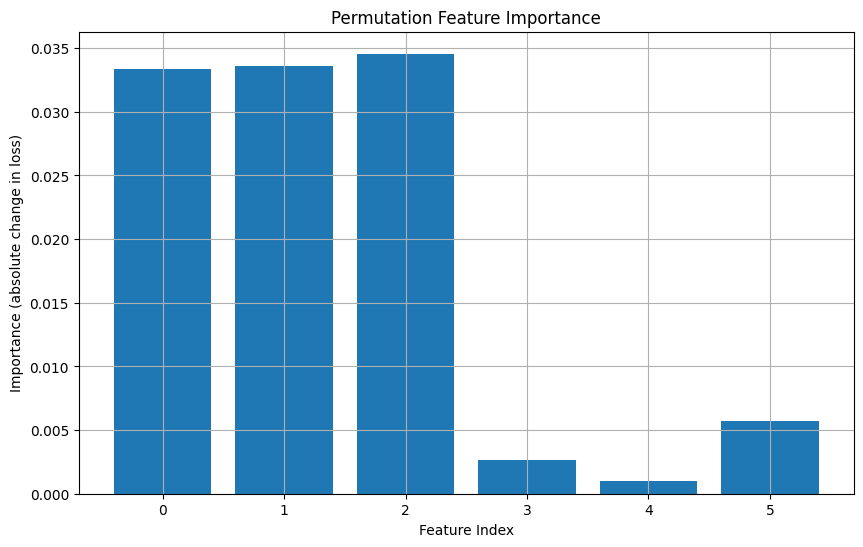

In [31]:
import torch
import numpy as np

def permutation_importance(model, X, y, metric, n_repeats=5):
    baseline = metric(model(X), y).item()
    importance = np.zeros(X.shape[1])

    for i in range(X.shape[1]):
        scores = []
        X_perm = X.clone()
        for _ in range(n_repeats):
            X_perm[:, i] = X_perm[torch.randperm(X_perm.size(0)), i]
            score = metric(model(X_perm), y).item()
            scores.append(score)
        importance[i] = np.mean(scores) - baseline
    return importance

# Calculate feature importance using permutation method
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.as_tensor(y_test, dtype=torch.float32)

# Use binary cross entropy as the metric
importances = permutation_importance(model, X_test_tensor, y_test_tensor, criterion)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), np.abs(importances))
plt.title('Permutation Feature Importance')
plt.xlabel('Feature Index')
plt.ylabel('Importance (absolute change in loss)')
plt.grid(True)
plt.show()



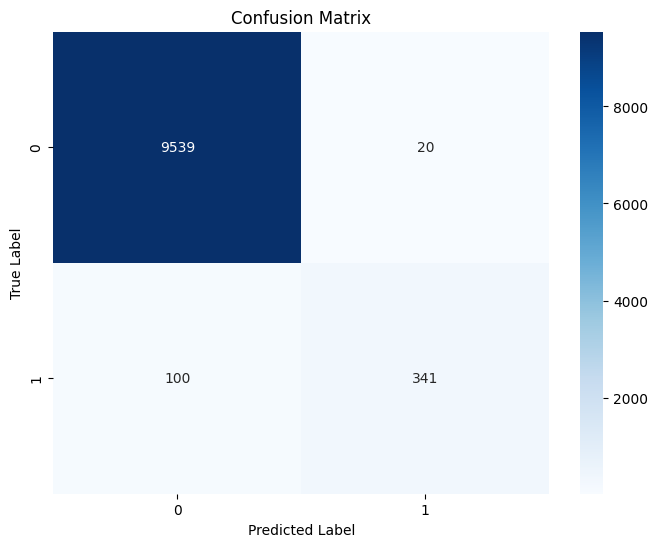

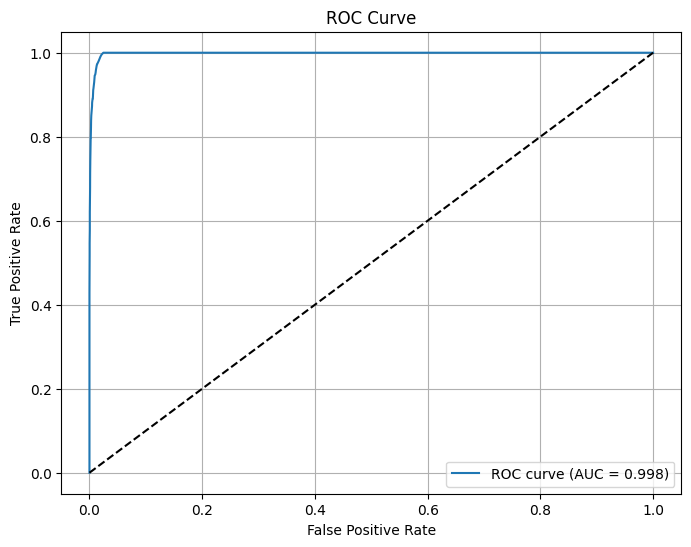

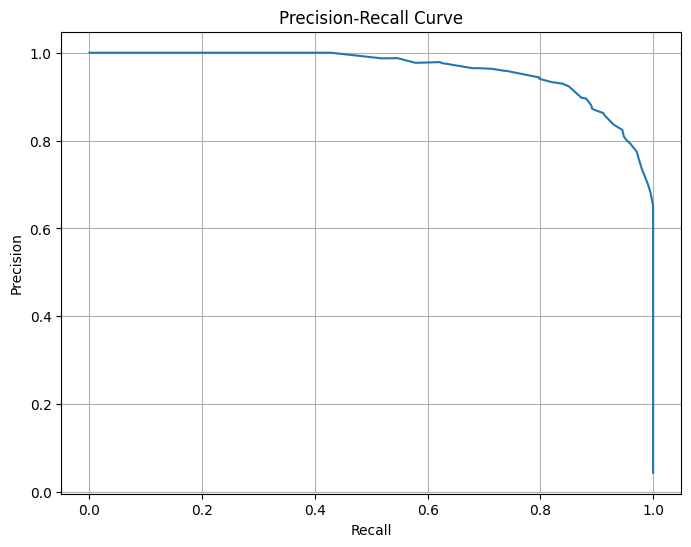

In [27]:
# Additional model evaluation steps:

# 1. Feature importance analysis
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importances)), importances)
    plt.title('Feature Importances')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()

# 2. Confusion Matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_calibrated_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_calibrated_prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_calibrated_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()